In [2]:
!pip install shap

   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/43.0 MB 3.0 MB/s eta 0:00:15
   - -------------------------------------- 1.3/43.0 MB 3.2 MB/s eta 0:00:13
   - -------------------------------------- 1.8/43.0 MB 3.2 MB/s eta 0:00:13
   -- ------------------------------------- 2.6/43.0 MB 3.4 MB/s eta 0:00:12
   --- ------------------------------------ 3.4/43.0 MB 3.4 MB/s eta 0:00:12
   --- ------------------------------------ 4.2/43.0 MB 3.4 MB/s eta 0:00:12
   ---- ----------------------------------- 4.7/43.0 MB 3.4 MB/s eta 0:00:12
   ---- ----------------------------------- 5.0/43.0 MB 3.0 MB/s eta 0:00:13
   ---- ----------------------------------- 5.2/43.0 MB 3.0 MB/s eta 0:00:13
   ----- ---------------------------------- 5.5/43.0 MB 2.8 MB/s eta 0:00:14
   ----- ---------------------------------- 5.8/43.0 MB 2.7 MB/s eta 0:00:14
   ----- ---------------------------------- 6.3/43.0 MB 2.5 MB/s eta 0:00:15
   ---


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\hp pro\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


✅ Loaded final dataset: 3917 rows, 18 columns

First 5 rows:
       SEQN  RIDAGEYR  INDFMPIR  DMDEDUC2  RHQ010  RHQ060  RHQ078  LBXTST  LBXFSH  LBXEST  LBXSHBG    SLQ300    SLQ310  ALQ130  HSQ590  depression_score  menopause_status menopause_label
0  130380.0      44.0      1.41       3.0    13.0     NaN     2.0    13.8    2.58    85.0    52.01  b'00:00'  b'08:00'     1.0     1.0      2.000000e+00               3.0   Postmenopause
1  130387.0      68.0      1.32       5.0    13.0    56.0     NaN    18.7   56.84    15.4    46.60  b'04:00'  b'07:00'     NaN     2.0      4.857845e-78               3.0   Postmenopause
2  130388.0      27.0      0.81       4.0     NaN     NaN     NaN     NaN     NaN     NaN      NaN  b'21:00'  b'06:30'     NaN     NaN               NaN               2.0   Perimenopause
3  130390.0      31.0      2.16       3.0     NaN     NaN     NaN    51.5    5.42   121.0    41.93  b'22:00'  b'06:00'     NaN     NaN               NaN               2.0   Perimenopause
4  1

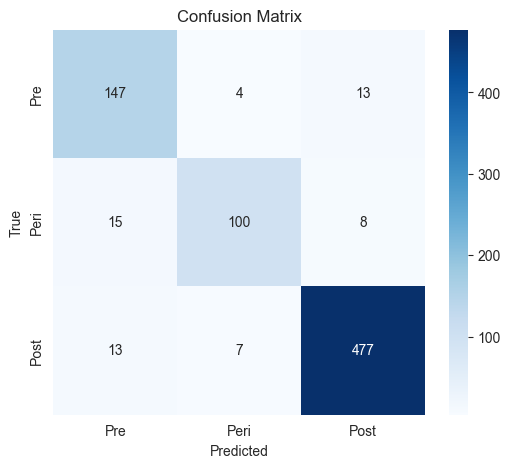


📈 Weighted AUC (One-vs-Rest): 0.986


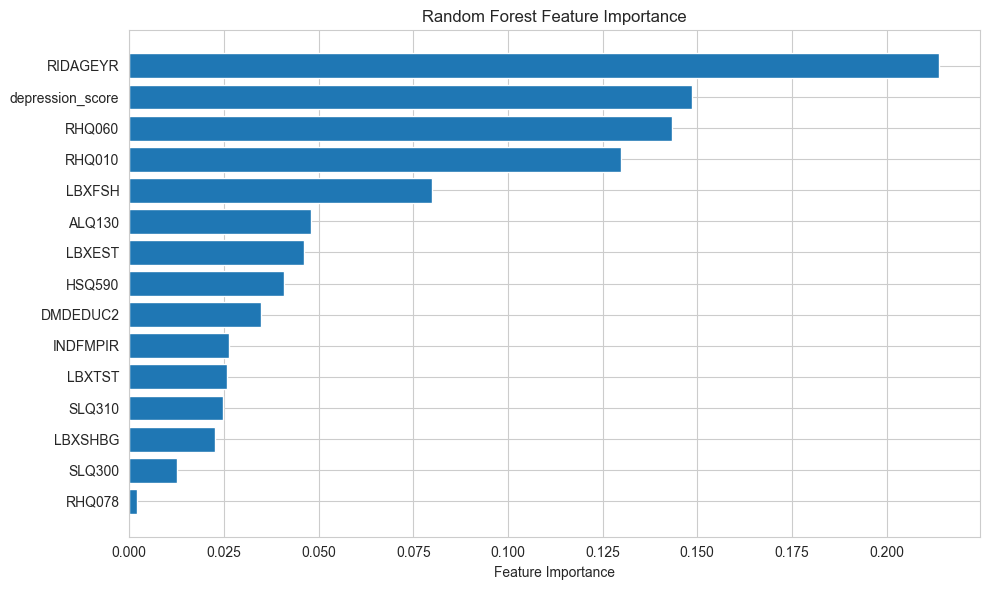

Background dataset has 3133 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3133 when initializing the masker.


Shape of X_train_shap: (3133, 15)


100%|===================| 9388/9399 [09:12<00:00]       Background dataset has 3133 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3133 when initializing the masker.


shap.Explainer failed: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 0.058982, while the model output was 0.042304. If this difference is acceptable you can set check_additivity=False to disable this check.


100%|===================| 9385/9399 [09:03<00:00]        

✅ Used shap.TreeExplainer with interventional and check_additivity=False
Shape of shap_class (Postmenopause): (3133, 15)


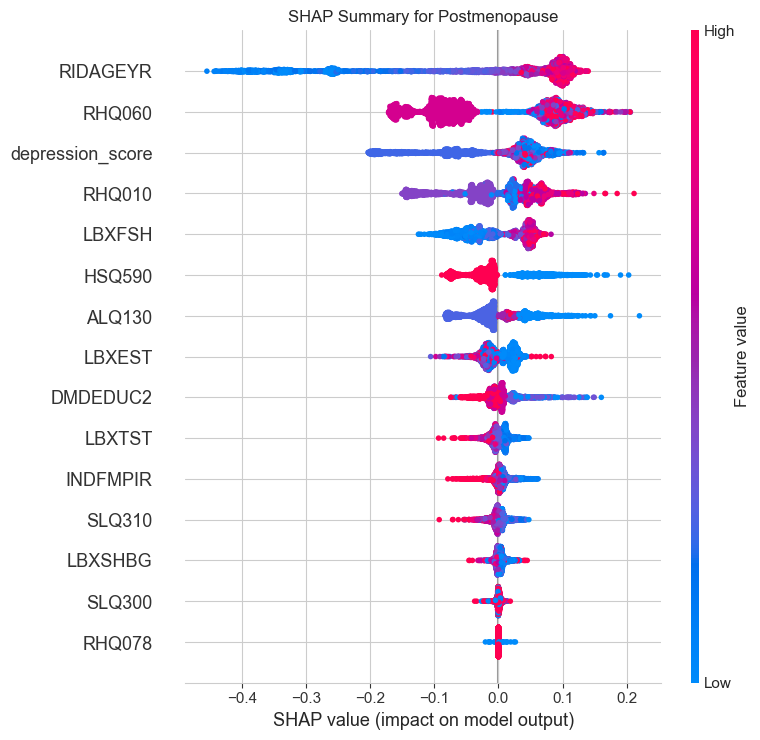

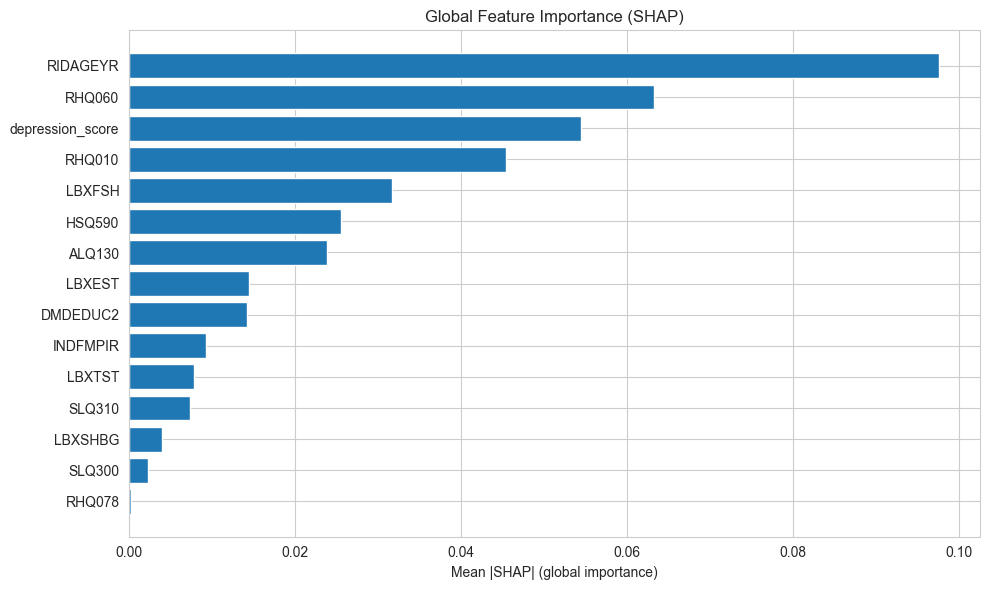

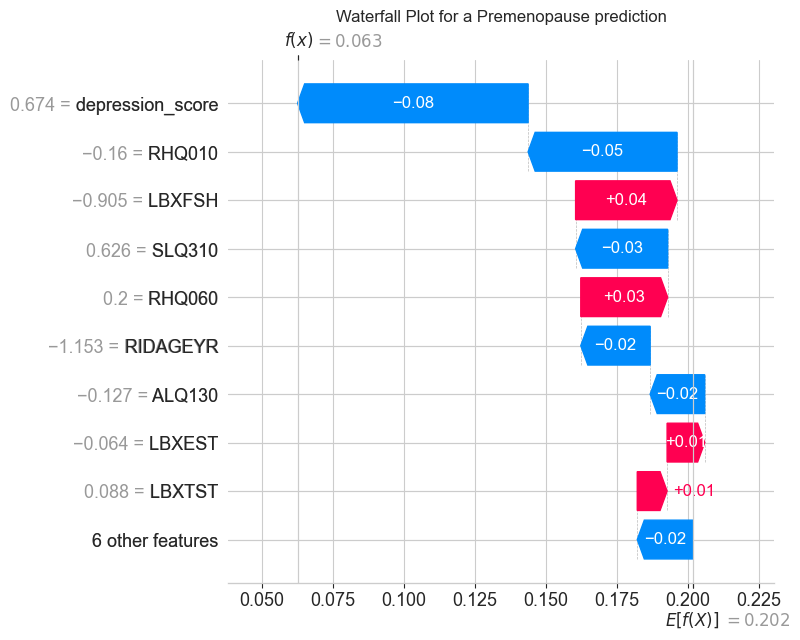

✅ Model saved to: ../Dataset/menopause_rf_model.pkl
✅ SHAP explainer saved to: ../Dataset/shap_explainer.pkl
✅ Feature names saved to: ../Dataset/feature_names.txt

🎉 Notebook 03 completed successfully!
   - Model trained and evaluated.
   - SHAP explanations generated.
   - Model and explainer saved for later use.


In [7]:
# %% [markdown]
# # Notebook 03: Model Training & SHAP Interpretability
#
# **Objective**:
# 1. Load the final dataset prepared in Notebook 02.
# 2. Preprocess predictors (handle missing values, encode time columns, standardize).
# 3. Split into train/test sets (stratified by target).
# 4. Train a Random Forest classifier (baseline) and optionally XGBoost.
# 5. Evaluate performance (classification report, confusion matrix, ROC-AUC).
# 6. Use SHAP to explain model predictions (global and local).
# 7. Save the model and SHAP results for further use.
#
# **Author**: Sara YOUSSE
# **Date**: 2026-07-18

# %%
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib
import shap

# Set options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_style('whitegrid')

# %%
# ------------------------------
# 1. Load the final dataset
# ------------------------------
data_path = "../Dataset/"
input_file = os.path.join(data_path, "final_features_target.pkl")
df = pd.read_pickle(input_file)
print(f"✅ Loaded final dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())

# %%
# ------------------------------
# 2. Clean remaining 5.397605e-79 values in depression_score and other cols
# ------------------------------
# Some participants still have 5.397605e-79 in depression_score (from DPQ sum)
# We replace it with NaN, then impute later.
cols_to_clean = ['depression_score', 'LBXTST', 'LBXFSH', 'LBXEST', 'LBXSHBG']
for col in cols_to_clean:
    if col in df.columns:
        df[col] = df[col].replace(5.397605e-79, np.nan)

print("✅ Cleaned remaining 5.397605e-79 values.")

# %%
# ------------------------------
# 3. Convert time columns (SLQ300, SLQ310) to numeric minutes
# ------------------------------
# These columns are stored as bytes like b'00:00' for bedtime and wake time.
# We want to convert them to minutes from midnight (or hours).
def time_bytes_to_minutes(b):
    """Convert bytes b'HH:MM' to total minutes from midnight."""
    if pd.isna(b):
        return np.nan
    if isinstance(b, bytes):
        s = b.decode('utf-8')
    else:
        s = str(b)
    try:
        h, m = map(int, s.split(':'))
        return h * 60 + m
    except:
        return np.nan

for col in ['SLQ300', 'SLQ310']:
    if col in df.columns:
        df[col + '_minutes'] = df[col].apply(time_bytes_to_minutes)
        # Drop the original bytes column
        df.drop(columns=[col], inplace=True)
        # Rename new column
        df.rename(columns={col + '_minutes': col}, inplace=True)

print("✅ Converted SLQ300 and SLQ310 to minutes.")

# %%
# ------------------------------
# 4. Separate predictors (X) and target (y)
# ------------------------------
# Drop SEQN, menopause_status, menopause_label (we use menopause_status as target)
X = df.drop(columns=['SEQN', 'menopause_status', 'menopause_label'])
y = df['menopause_status'].astype(int)  # 1,2,3

# For SHAP later, we also keep the feature names
feature_names = X.columns.tolist()
print(f"\n🔢 Features ({len(feature_names)}): {feature_names}")
print(f"\n🎯 Target distribution:\n{y.value_counts().sort_index()}")

# %%
# ------------------------------
# 5. Split data (stratified)
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# %%
# ------------------------------
# 6. Preprocessing pipeline
# ------------------------------
# We impute missing values with median (for numeric columns) and standardize.
# For the time columns, they are now numeric (minutes).
numeric_cols = X_train.columns.tolist()  # all are numeric now

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols)
    ])

# %%
# ------------------------------
# 7. Define model (Random Forest)
# ------------------------------
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Create full pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

# %%
# ------------------------------
# 8. Cross-validation (optional)
# ------------------------------
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
print(f"\n📊 Cross-validation accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# %%
# ------------------------------
# 9. Train the model
# ------------------------------
pipeline.fit(X_train, y_train)
print("✅ Model trained.")

# %%
# ------------------------------
# 10. Evaluation on test set
# ------------------------------
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)  # for ROC-AUC

print("\n" + "="*50)
print("📊 CLASSIFICATION REPORT (Test Set)")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Premenopause', 'Perimenopause', 'Postmenopause']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pre', 'Peri', 'Post'],
            yticklabels=['Pre', 'Peri', 'Post'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# ROC-AUC (One-vs-Rest)
try:
    auc_ovr = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    print(f"\n📈 Weighted AUC (One-vs-Rest): {auc_ovr:.3f}")
except:
    print("ROC-AUC not computed (check if all classes present).")

# %%
# ------------------------------
# 11. Feature importance (built-in)
# ------------------------------
# Extract the trained classifier from the pipeline
clf = pipeline.named_steps['classifier']
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# %%
# ------------------------------
# 12. SHAP Explainability (corrected)
# ------------------------------

# Extract the classifier from the pipeline
clf = pipeline.named_steps['classifier']

# Get preprocessed training data (scaled)
preprocessor = pipeline.named_steps['preprocessor']
X_train_transformed = preprocessor.transform(X_train)
X_train_shap = pd.DataFrame(X_train_transformed, columns=feature_names)

print(f"Shape of X_train_shap: {X_train_shap.shape}")

# Try using the new shap.Explainer API (preferred)
try:
    # For newer SHAP versions (>=0.41)
    explainer = shap.Explainer(clf, X_train_shap, feature_names=feature_names)
    shap_values = explainer.shap_values(X_train_shap)
    print("✅ Used shap.Explainer")
except Exception as e:
    print(f"shap.Explainer failed: {e}")
    # Fallback to TreeExplainer with check_additivity=False and feature_perturbation='interventional'
    try:
        explainer = shap.TreeExplainer(clf, X_train_shap, feature_perturbation='interventional')
        shap_values = explainer.shap_values(X_train_shap, check_additivity=False)
        print("✅ Used shap.TreeExplainer with interventional and check_additivity=False")
    except Exception as e2:
        print(f"TreeExplainer also failed: {e2}")
        # Ultimate fallback: use TreeExplainer with raw data (not standardized) but this may not be accurate
        # We'll skip SHAP for now
        print("⚠️ SHAP failed. Skipping SHAP plots.")
        shap_values = None

# Only proceed if shap_values is not None
if shap_values is not None:
    # Determine the structure of shap_values
    if isinstance(shap_values, list):
        # TreeExplainer returns a list of arrays per class
        shap_values_array = np.array(shap_values)  # (n_classes, n_samples, n_features)
        shap_class = shap_values[2]  # Postmenopause class (index 2)
        expected_value = explainer.expected_value
    else:
        # Explainer returns a 3D array (n_samples, n_features, n_classes)
        shap_values_array = shap_values
        shap_class = shap_values[:, :, 2]  # Postmenopause class
        expected_value = explainer.expected_value

    print(f"Shape of shap_class (Postmenopause): {shap_class.shape}")

    # Summary plot for Postmenopause
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_class, X_train_shap, feature_names=feature_names, show=False)
    plt.title('SHAP Summary for Postmenopause')
    plt.tight_layout()
    plt.show()

    # Global importance (mean |SHAP| across all classes and samples)
    if isinstance(shap_values, list):
        global_importance = np.mean(np.abs(shap_values_array), axis=(0, 1))
    else:
        global_importance = np.mean(np.abs(shap_values), axis=(0, 2))
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Mean |SHAP|': global_importance
    }).sort_values('Mean |SHAP|', ascending=False)

    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Mean |SHAP|'])
    plt.xlabel('Mean |SHAP| (global importance)')
    plt.title('Global Feature Importance (SHAP)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # Waterfall plot for one test instance
    X_test_transformed = preprocessor.transform(X_test)
    X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names)
    x_sample = X_test_shap.iloc[0:1]

    pred_class = pipeline.predict(X_test.iloc[0:1])[0]
    class_idx = pred_class - 1

    if isinstance(shap_values, list):
        shap_sample = shap_values[class_idx][0]
        base_value = expected_value[class_idx]
    else:
        shap_sample = shap_values[0, :, class_idx]
        base_value = expected_value[class_idx]

    # Map class to label
    class_map = {1: 'Premenopause', 2: 'Perimenopause', 3: 'Postmenopause'}
    pred_label = class_map[pred_class]

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_sample,
            base_values=base_value,
            data=X_test_shap.iloc[0],
            feature_names=feature_names
        ),
        show=False
    )
    plt.title(f'Waterfall Plot for a {pred_label} prediction')
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ SHAP analysis skipped due to errors. Proceeding with model saving.")

# %%
# ------------------------------
# 13. Save the model and SHAP explainer
# ------------------------------
model_path = os.path.join(data_path, "menopause_rf_model.pkl")
joblib.dump(pipeline, model_path)
print(f"✅ Model saved to: {model_path}")

shap_explainer_path = os.path.join(data_path, "shap_explainer.pkl")
joblib.dump(explainer, shap_explainer_path)
print(f"✅ SHAP explainer saved to: {shap_explainer_path}")

# Also save the feature names for future use
feat_path = os.path.join(data_path, "feature_names.txt")
with open(feat_path, 'w') as f:
    for name in feature_names:
        f.write(name + '\n')
print(f"✅ Feature names saved to: {feat_path}")

# %%
print("\n🎉 Notebook 03 completed successfully!")
print("   - Model trained and evaluated.")
print("   - SHAP explanations generated.")
print("   - Model and explainer saved for later use.")